# TB Treatment Outcome Prediction — ML Model Benchmarking

**Dataset:** TB Case Notifications, Cordillera Administrative Region (CAR), Philippines (2015–2025)  
**Task:** Binary classification — predict **Treatment Success** vs **Treatment Failure**  
**Approach:** Benchmark 10 ML models using demographic and clinical features

### Target Definition
| Label | Outcome/Status values |
|---|---|
| **Success (1)** | TREATMENT COMPLETED, CURED |
| **Failure (0)** | DIED, LOST TO FF-UP, FAILED |

> Records with ambiguous status (ON TREATMENT, EXCLUDED, DIAGNOSED, NOT EVALUATED, NOT ENROLLED, Screened) are excluded.

## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Utilities
import time
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
img_dir = Path('outputs/images')
model_dir = Path('outputs/models')
img_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading and Target Engineering

In [2]:
# Load the consolidated clean dataset (raw values — better for interpretable preprocessing)
df_raw = pd.read_csv('dataset/non-temporal/2015-2025-consolidated-clean.csv')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')

Raw dataset shape: (7389, 28)
Columns: ['Type', 'Validation Status', 'Date of Screening', 'Date of Diagnosis', 'Date of Notification', 'Birthdate', 'Age', 'Sex', 'Brgy', 'City/Municipality', 'Province', 'Region', 'Screening/Diagnosing Health Facility', 'Treatment Health Facility', 'Source of Patient', 'Anatomical Site', 'Registration Group', 'Bacteriologic Status', 'Microscopy Result', 'Microscopy Release Date', 'RDT Result', 'RDT Release Date', 'Date Started Tx', 'Outcome/Status', 'Date of Outcome/Status', 'Year', 'Days_To_Treatment', 'Computed_Age']


Usable records after removing ambiguous outcomes: 6,797
Excluded (ambiguous): 592

Target distribution:
  Success (1): 5,858 (86.2%)
  Failure (0): 939 (13.8%)


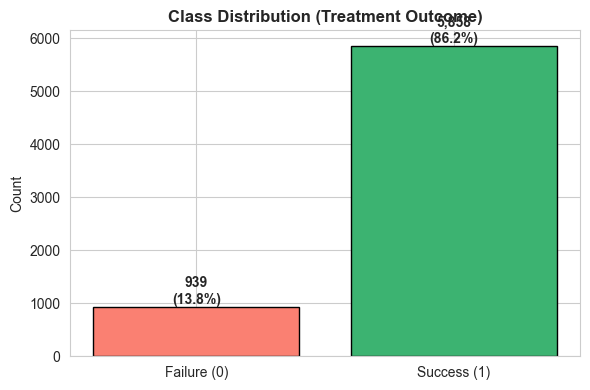

In [3]:
# Define target variable
SUCCESS_OUTCOMES = {'TREATMENT COMPLETED', 'CURED'}
FAILURE_OUTCOMES  = {'DIED', 'LOST TO FF-UP', 'FAILED'}

df = df_raw[df_raw['Outcome/Status'].isin(SUCCESS_OUTCOMES | FAILURE_OUTCOMES)].copy()
df['Target'] = df['Outcome/Status'].apply(lambda x: 1 if x in SUCCESS_OUTCOMES else 0)

print(f'Usable records after removing ambiguous outcomes: {len(df):,}')
print(f"Excluded (ambiguous): {len(df_raw) - len(df):,}")
print()

class_counts = df['Target'].value_counts()
print('Target distribution:')
print(f"  Success (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Failure (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)")

# Visualise class balance
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Failure (0)', 'Success (1)'], class_counts[[0, 1]].values,
              color=['salmon', 'mediumseagreen'], edgecolor='black')
for bar, val in zip(bars, class_counts[[0, 1]].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Treatment Outcome)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [4]:
# ── Feature selection ────────────────────────────────────────────────────────
# Numeric features
NUM_FEATURES = ['Age', 'Days_To_Treatment', 'Year']

# Low-cardinality categorical features (will be one-hot encoded)
CAT_FEATURES = [
    'Sex',
    'Anatomical Site',
    'Registration Group',
    'Bacteriologic Status',
    'Microscopy Result',
    'Source of Patient',
    'Type',                   # DSTB / DRTB
]

# Medium-cardinality — ordinal encode to keep dimensionality manageable
ORD_FEATURES = ['Province']

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + ORD_FEATURES

X = df[ALL_FEATURES].copy()
y = df['Target'].values

# Derive Age from Computed_Age if Age is NaN
X['Age'] = X['Age'].fillna(df['Computed_Age'])

# Replace 0 Days_To_Treatment with NaN (likely missing, not same day)
X['Days_To_Treatment'] = X['Days_To_Treatment'].replace(0, np.nan)

print(f'Feature matrix shape: {X.shape}')
print(f'\nMissing values per feature:')
print(X.isnull().sum())

Feature matrix shape: (6797, 11)

Missing values per feature:
Age                        0
Days_To_Treatment        825
Year                       0
Sex                        0
Anatomical Site            0
Registration Group         0
Bacteriologic Status       0
Microscopy Result       2174
Source of Patient          0
Type                       0
Province                  70
dtype: int64


## 4. Preprocessing Pipeline

In [5]:
# ── Build sklearn ColumnTransformer ────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,      NUM_FEATURES),
    ('cat', categorical_transformer,  CAT_FEATURES),
    ('ord', ordinal_transformer,      ORD_FEATURES),
])

# ── Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train class balance — Success: {y_train.sum():,} / Failure: {(y_train==0).sum():,}')
print(f'Test  class balance — Success: {y_test.sum():,} / Failure: {(y_test==0).sum():,}')

Train size: 5,437  |  Test size: 1,360
Train class balance — Success: 4,686 / Failure: 751
Test  class balance — Success: 1,172 / Failure: 188


## 5. Model Definitions

In [7]:
# ── Define model zoo ───────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
        n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced',
        n_jobs=-1, verbose=-1
    ),
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        max_iter=500, random_state=RANDOM_STATE, early_stopping=True,
        validation_fraction=0.1, learning_rate_init=0.001
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', probability=True, random_state=RANDOM_STATE,
        class_weight='balanced', C=1.0, gamma='scale'
    ),
}

print(f'{len(MODELS)} models defined:')
for name in MODELS:
    print(f'  • {name}')

12 models defined:
  • Logistic Regression
  • Naive Bayes
  • K-Nearest Neighbors
  • Decision Tree
  • Random Forest
  • Extra Trees
  • AdaBoost
  • Gradient Boosting
  • XGBoost
  • LightGBM
  • MLP Neural Network
  • SVM (RBF)


## 6. Training and Benchmarking

In [8]:
# ── Train all models, collect metrics ─────────────────────────────────────
results = []
trained_pipelines = {}

# Naive Bayes needs dense array — preprocessor already returns dense via sparse_output=False

for name, model in MODELS.items():
    print(f'Training {name}...', end='  ', flush=True)
    t0 = time.time()

    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    train_time = time.time() - t0

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model':      name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, zero_division=0),
        'Recall':     recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':   f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'Train Time (s)': round(train_time, 2),
    })
    trained_pipelines[name] = pipe
    print(f'done ({train_time:.1f}s)')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index += 1

# Format for display
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    display_df[col] = display_df[col].map('{:.4f}'.format)

print('\n' + '='*85)
print('MODEL BENCHMARKING RESULTS (sorted by ROC-AUC)')
print('='*85)
print(display_df.to_string())

Training Logistic Regression...  done (0.6s)
Training Naive Bayes...  done (0.1s)
Training K-Nearest Neighbors...  done (0.1s)
Training Decision Tree...  done (0.1s)
Training Random Forest...  done (0.8s)
Training Extra Trees...  done (0.7s)
Training AdaBoost...  done (0.7s)
Training Gradient Boosting...  done (2.4s)
Training XGBoost...  done (0.7s)
Training LightGBM...  done (2.2s)
Training MLP Neural Network...  done (1.2s)
Training SVM (RBF)...  done (11.6s)

MODEL BENCHMARKING RESULTS (sorted by ROC-AUC)
                  Model Accuracy Precision  Recall F1-Score ROC-AUC  Train Time (s)
1             SVM (RBF)   0.6250    0.8988  0.6365   0.7453  0.6367           11.64
2   Logistic Regression   0.6125    0.8967  0.6220   0.7345  0.6259            0.63
3              AdaBoost   0.8618    0.8618  1.0000   0.9258  0.6204            0.68
4     Gradient Boosting   0.8603    0.8632  0.9957   0.9247  0.6040            2.44
5    MLP Neural Network   0.8618    0.8618  1.0000   0.9258  0.603

## 7. Results Visualisation

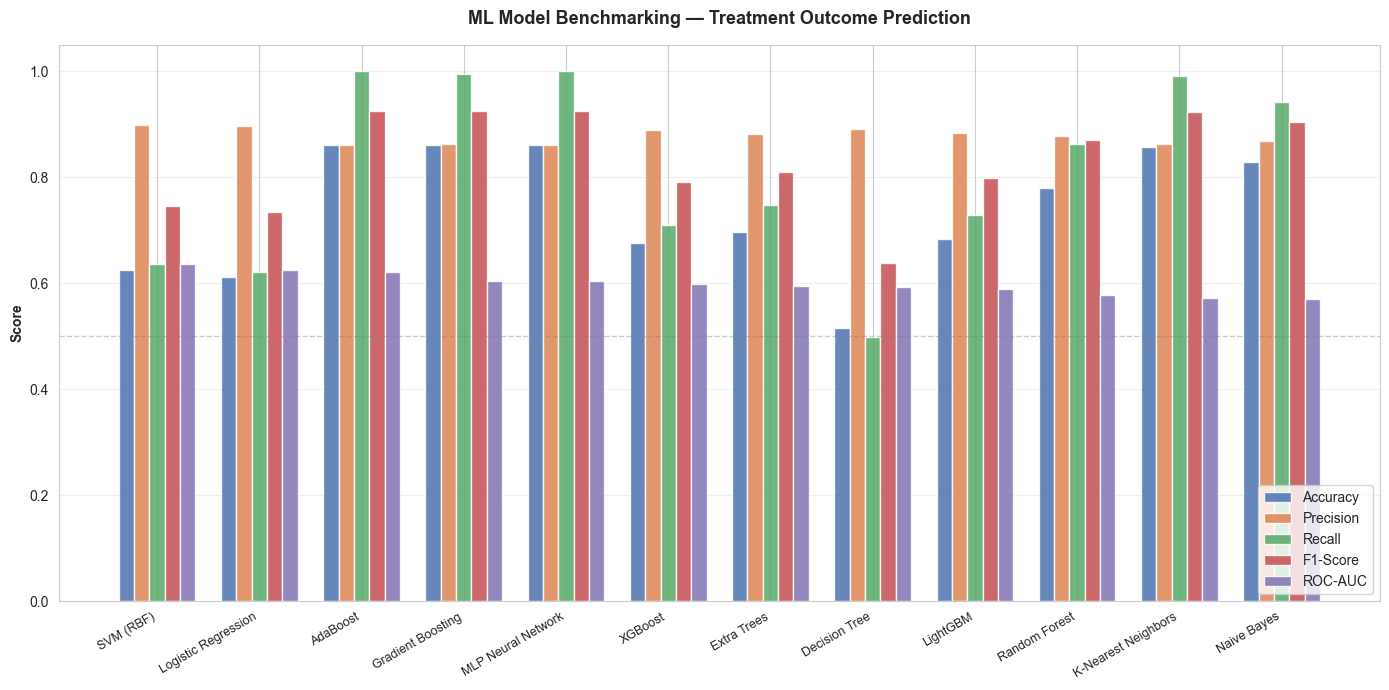

Saved: benchmark_comparison.png


In [9]:
# ── Benchmark comparison bar chart ────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(plot_df))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, plot_df[metric].values, width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('ML Model Benchmarking — Treatment Outcome Prediction', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/images/benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison.png')

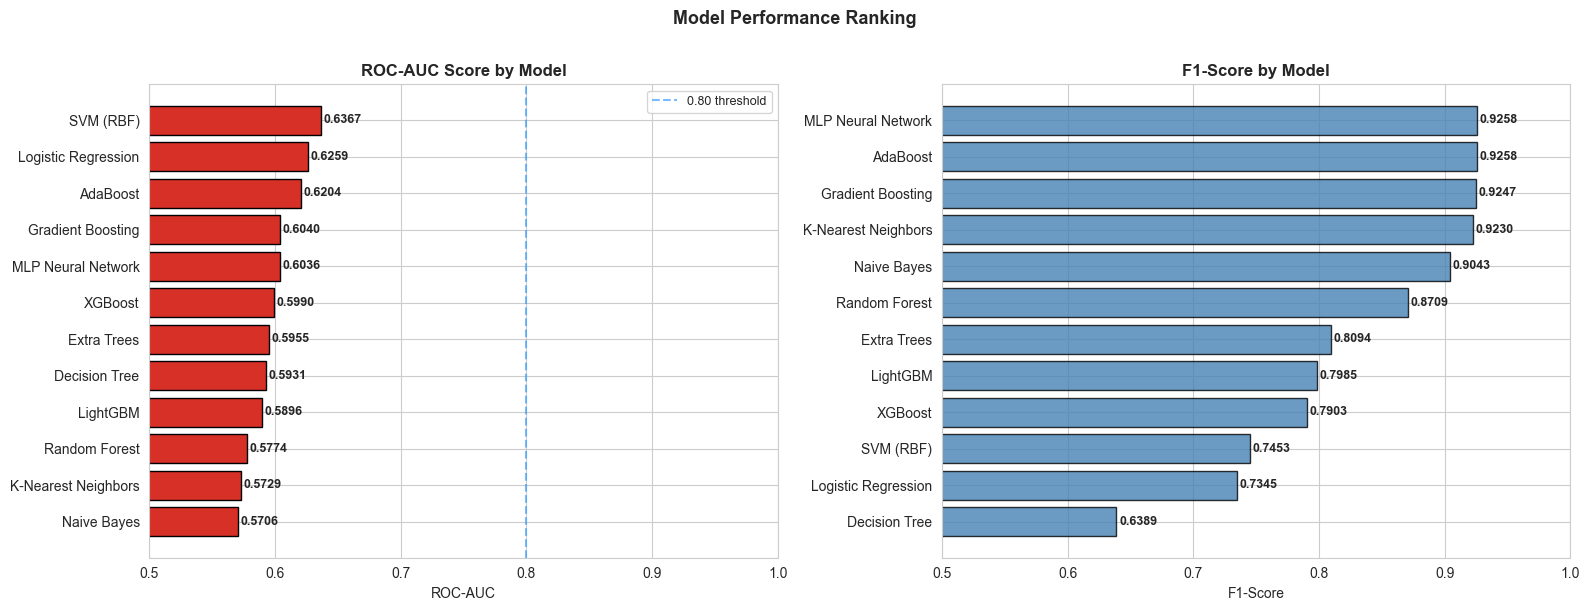

In [10]:
# ── ROC-AUC heatmap / ranking ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC by model
sorted_roc = results_df.sort_values('ROC-AUC', ascending=True)
colors_roc = ['#d73027' if v < 0.70 else '#fee08b' if v < 0.80 else '#1a9850'
               for v in sorted_roc['ROC-AUC']]
bars = axes[0].barh(sorted_roc['Model'], sorted_roc['ROC-AUC'], color=colors_roc, edgecolor='black')
for bar, val in zip(bars, sorted_roc['ROC-AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.8, color='dodgerblue', linestyle='--', alpha=0.6, label='0.80 threshold')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[0].set_xlabel('ROC-AUC')

# F1-Score by model
sorted_f1 = results_df.sort_values('F1-Score', ascending=True)
bars2 = axes[1].barh(sorted_f1['Model'], sorted_f1['F1-Score'], color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, sorted_f1['F1-Score']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
axes[1].set_title('F1-Score by Model', fontweight='bold')
axes[1].set_xlabel('F1-Score')

plt.suptitle('Model Performance Ranking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/images/model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

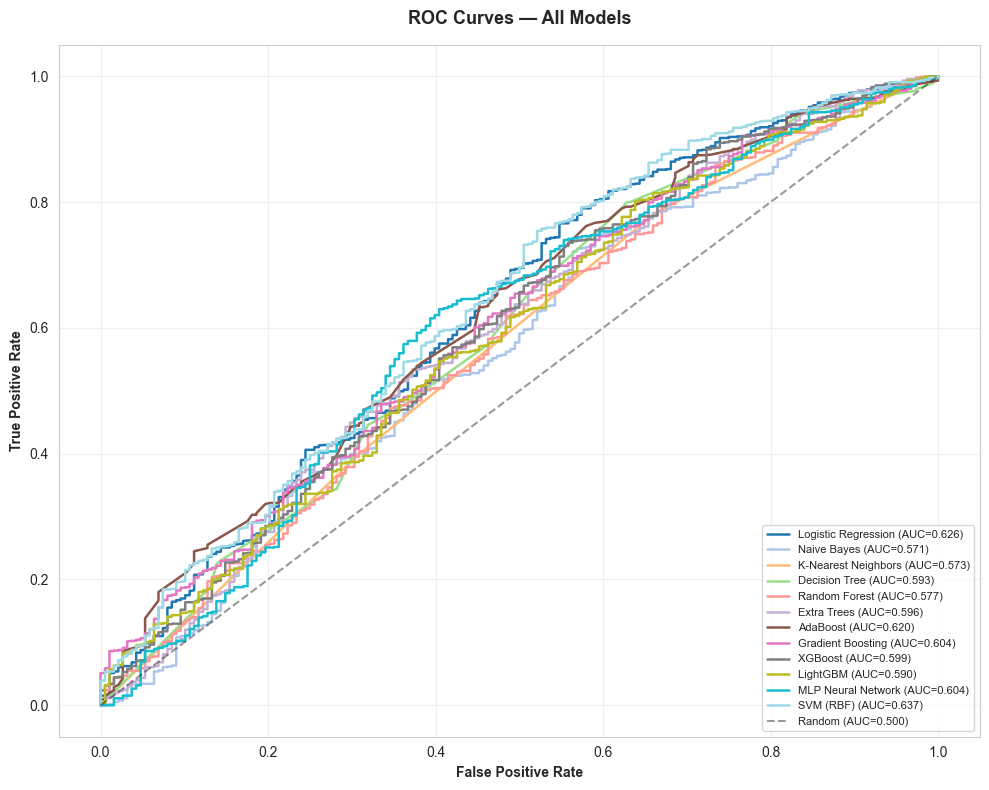

Saved: roc_curves_all_models.png


In [11]:
# ── ROC Curves for all models ──────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.cm.get_cmap('tab20', len(MODELS))

for i, (name, pipe) in enumerate(trained_pipelines.items()):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=cmap(i), linewidth=1.8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/images/roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_all_models.png')

## 8. Best Model — Detailed Analysis

In [12]:
# ── Identify best model by ROC-AUC ────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_model_name]
print(f'Best model: {best_model_name}')
print(f"  ROC-AUC : {results_df.iloc[0]['ROC-AUC']:.4f}")
print(f"  F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")

y_pred_best  = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Failure', 'Success']))

Best model: SVM (RBF)
  ROC-AUC : 0.6367
  F1-Score: 0.7453

Classification Report:
              precision    recall  f1-score   support

     Failure       0.20      0.55      0.29       188
     Success       0.90      0.64      0.75      1172

    accuracy                           0.62      1360
   macro avg       0.55      0.59      0.52      1360
weighted avg       0.80      0.62      0.68      1360



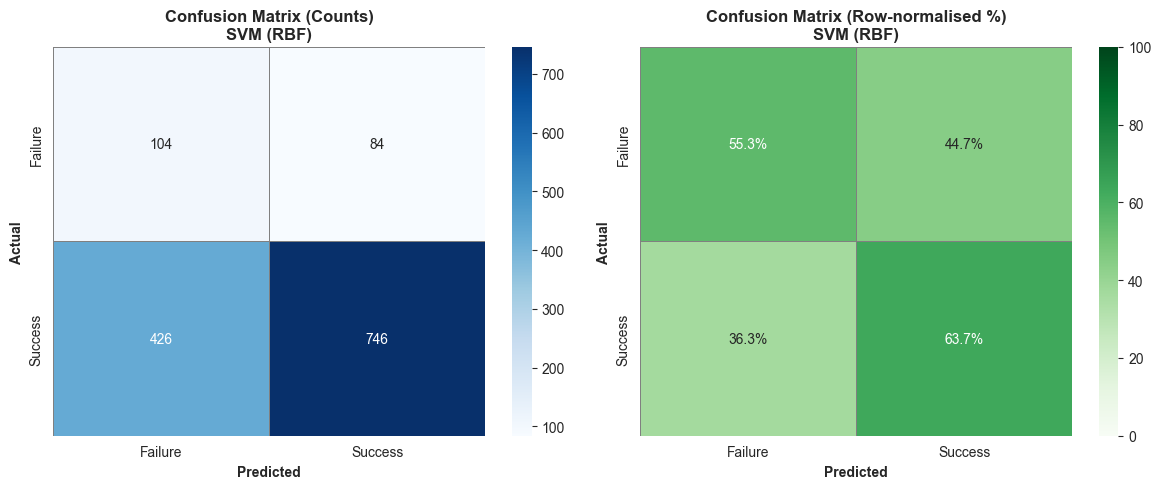

In [13]:
# ── Confusion matrix for best model ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_model_name}', fontweight='bold')

# Percentages per row (normalised)
labels = [[f'{v:.1f}%' for v in row] for row in cm_pct]
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Greens', ax=axes[1],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title(f'Confusion Matrix (Row-normalised %)\n{best_model_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/images/confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance

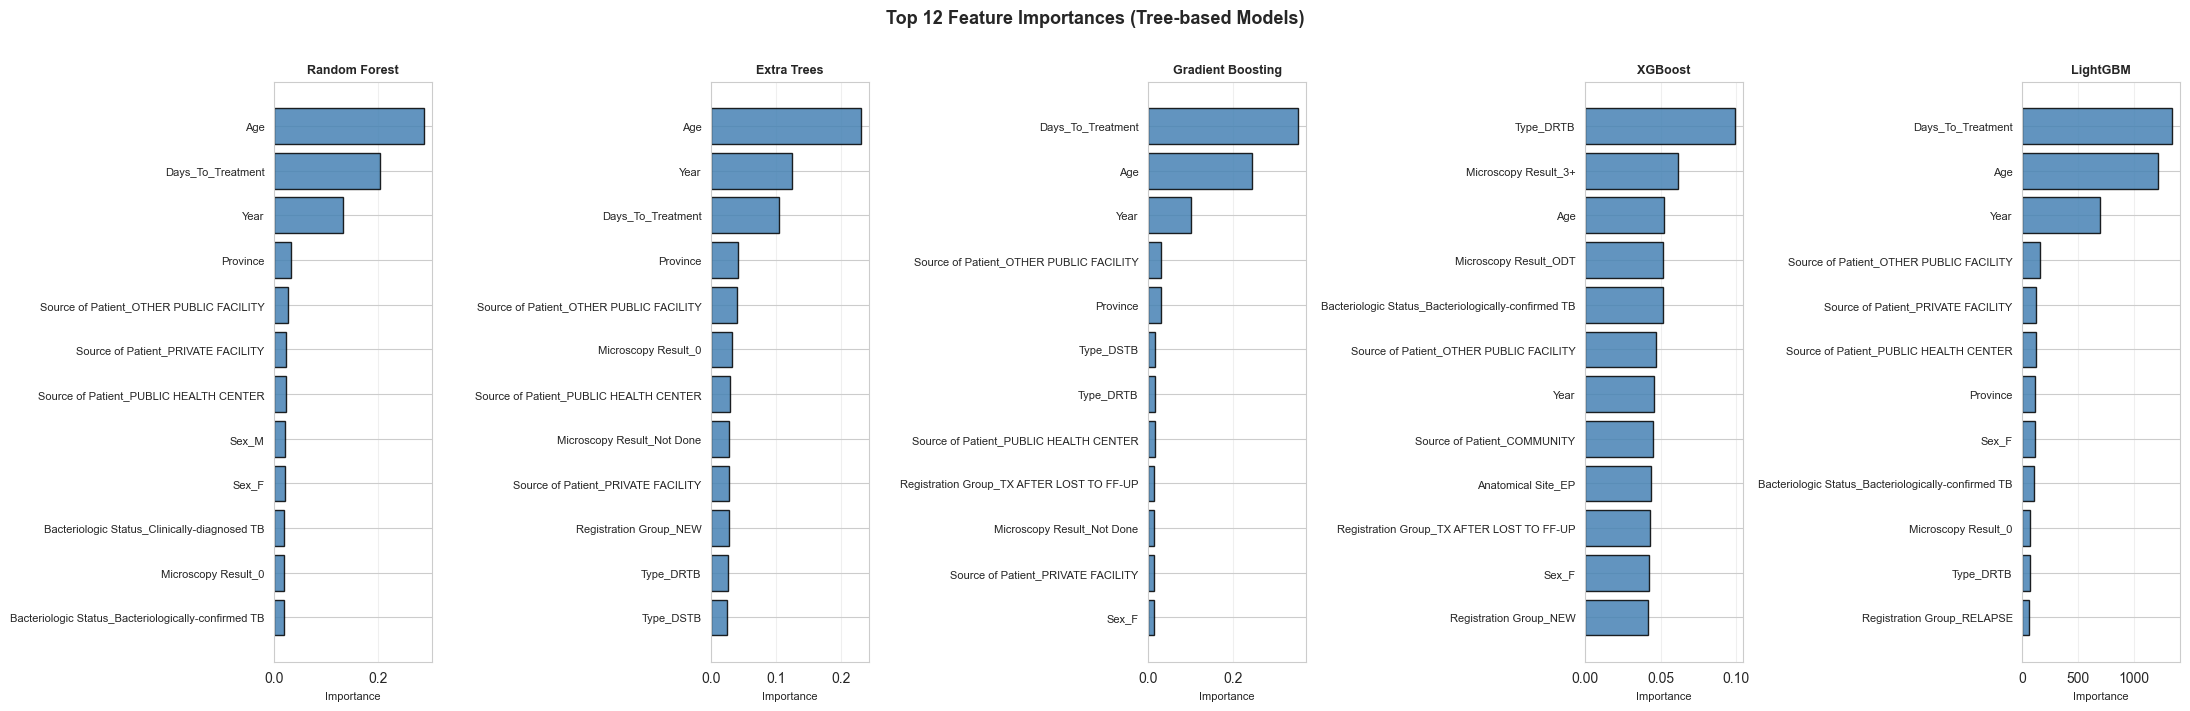

Saved: feature_importance_tree_models.png


In [14]:
# ── Feature importance from tree-based models ─────────────────────────────
def get_feature_names(pipe):
    """Extract feature names after preprocessing."""
    ct = pipe.named_steps['preprocessor']
    num_names = NUM_FEATURES
    cat_names = list(ct.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(CAT_FEATURES))
    ord_names = ORD_FEATURES
    return num_names + cat_names + ord_names

TREE_MODELS = ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(22, 7))

for ax, model_name in zip(axes, TREE_MODELS):
    pipe    = trained_pipelines[model_name]
    clf     = pipe.named_steps['classifier']
    feat_names = get_feature_names(pipe)
    importances = clf.feature_importances_

    # Top 12 features
    top_idx   = np.argsort(importances)[-12:]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    ax.barh(range(12), top_vals, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_yticks(range(12))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(model_name, fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 12 Feature Importances (Tree-based Models)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/images/feature_importance_tree_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_tree_models.png')

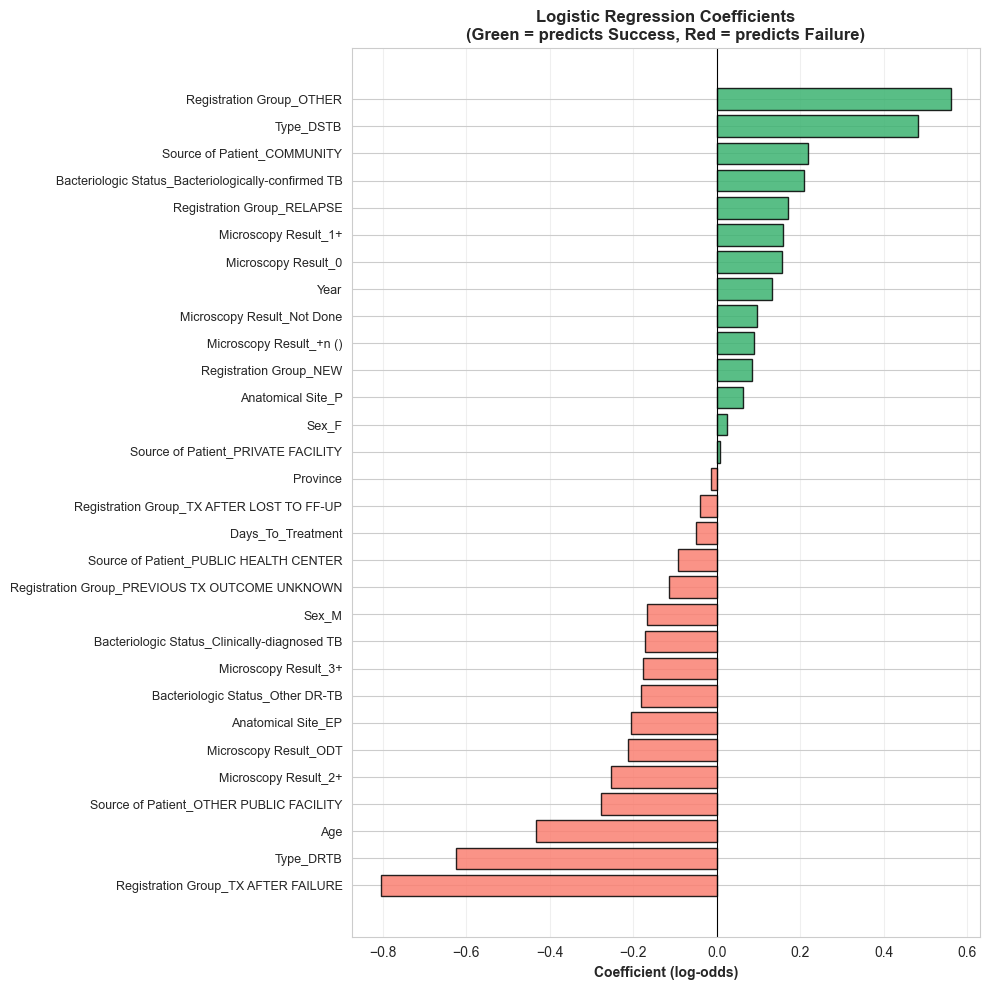

In [15]:
# ── Logistic Regression coefficients ──────────────────────────────────────
lr_pipe  = trained_pipelines['Logistic Regression']
lr_clf   = lr_pipe.named_steps['classifier']
feat_names = get_feature_names(lr_pipe)
coefs    = lr_clf.coef_[0]

top_n = 15
top_pos_idx = np.argsort(coefs)[-top_n:]
top_neg_idx = np.argsort(coefs)[:top_n]
selected = np.concatenate([top_neg_idx, top_pos_idx])

x_vals  = coefs[selected]
x_names = [feat_names[i] for i in selected]

colors_lr = ['salmon' if v < 0 else 'mediumseagreen' for v in x_vals]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(x_vals)), x_vals, color=colors_lr, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(x_vals)))
ax.set_yticklabels(x_names, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title('Logistic Regression Coefficients\n(Green = predicts Success, Red = predicts Failure)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/images/logreg_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cross-Validation

In [16]:
# ── 5-fold stratified cross-validation on full dataset ────────────────────
CV_MODELS = {
    'Logistic Regression': MODELS['Logistic Regression'],
    'Random Forest':       MODELS['Random Forest'],
    'Gradient Boosting':   MODELS['Gradient Boosting'],
    'XGBoost':             MODELS['XGBoost'],
    'LightGBM':            MODELS['LightGBM'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in CV_MODELS.items():
    print(f'Cross-validating {name}...', end=' ', flush=True)
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=-1
    )
    cv_results.append({
        'Model':         name,
        'CV Accuracy':   f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV F1':         f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':    f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV Recall':     f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV Precision':  f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    })
    print('done')

cv_df = pd.DataFrame(cv_results)
print('\n5-Fold Stratified Cross-Validation Results:')
print(cv_df.to_string(index=False))

Cross-validating Logistic Regression... done
Cross-validating Random Forest... done
Cross-validating Gradient Boosting... done
Cross-validating XGBoost... done
Cross-validating LightGBM... done

5-Fold Stratified Cross-Validation Results:
              Model     CV Accuracy           CV F1      CV ROC-AUC       CV Recall    CV Precision
Logistic Regression 0.6064 ± 0.0138 0.7279 ± 0.0125 0.6323 ± 0.0134 0.6113 ± 0.0173 0.9000 ± 0.0045
      Random Forest 0.7830 ± 0.0122 0.8737 ± 0.0084 0.6082 ± 0.0230 0.8716 ± 0.0174 0.8760 ± 0.0020
  Gradient Boosting 0.8549 ± 0.0031 0.9215 ± 0.0017 0.6219 ± 0.0205 0.9874 ± 0.0036 0.8638 ± 0.0020
            XGBoost 0.6756 ± 0.0114 0.7918 ± 0.0081 0.6178 ± 0.0204 0.7159 ± 0.0102 0.8857 ± 0.0063
           LightGBM 0.6853 ± 0.0114 0.7992 ± 0.0082 0.6130 ± 0.0238 0.7267 ± 0.0106 0.8878 ± 0.0054


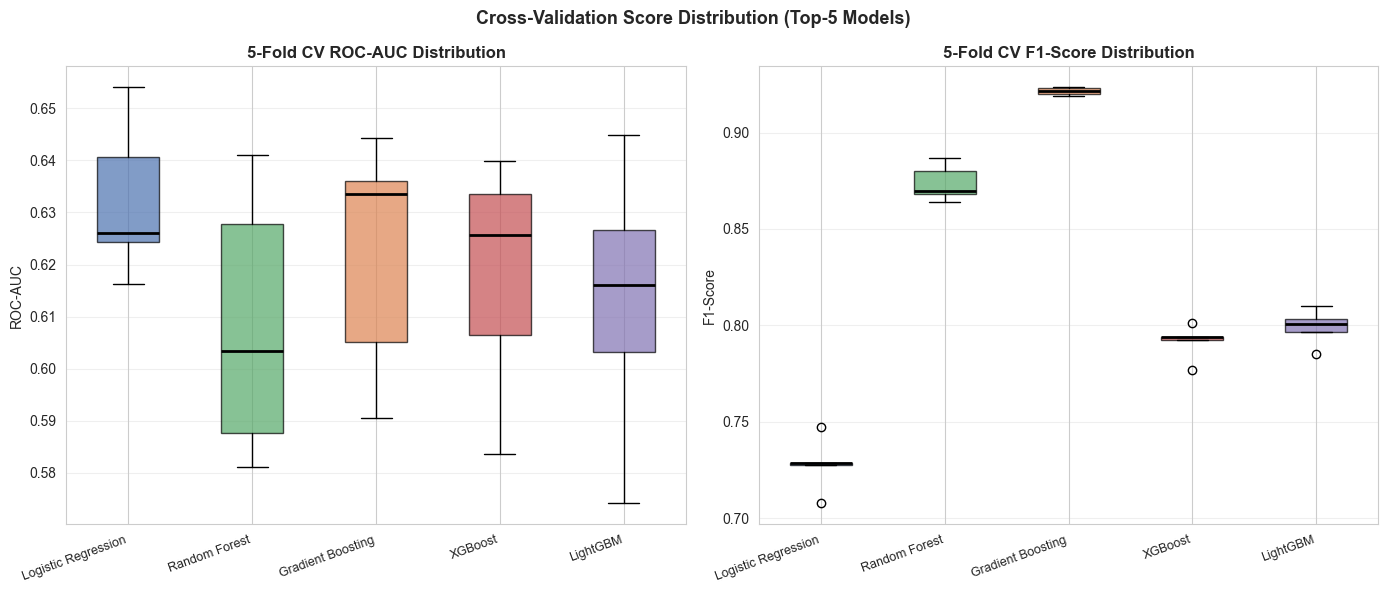

In [17]:
# ── CV ROC-AUC boxplot ─────────────────────────────────────────────────────
cv_box_data = {}
for name, model in CV_MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=['roc_auc', 'f1'], n_jobs=-1)
    cv_box_data[name] = {
        'roc_auc': scores['test_roc_auc'],
        'f1':      scores['test_f1'],
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    box_vals = [cv_box_data[n][metric] for n in CV_MODELS]
    bp = ax.boxplot(box_vals, labels=list(CV_MODELS.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors_box = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(list(CV_MODELS.keys()), rotation=20, ha='right', fontsize=9)
    ax.set_title(f'5-Fold CV {title} Distribution', fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Score Distribution (Top-5 Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/images/cv_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrices — All Models

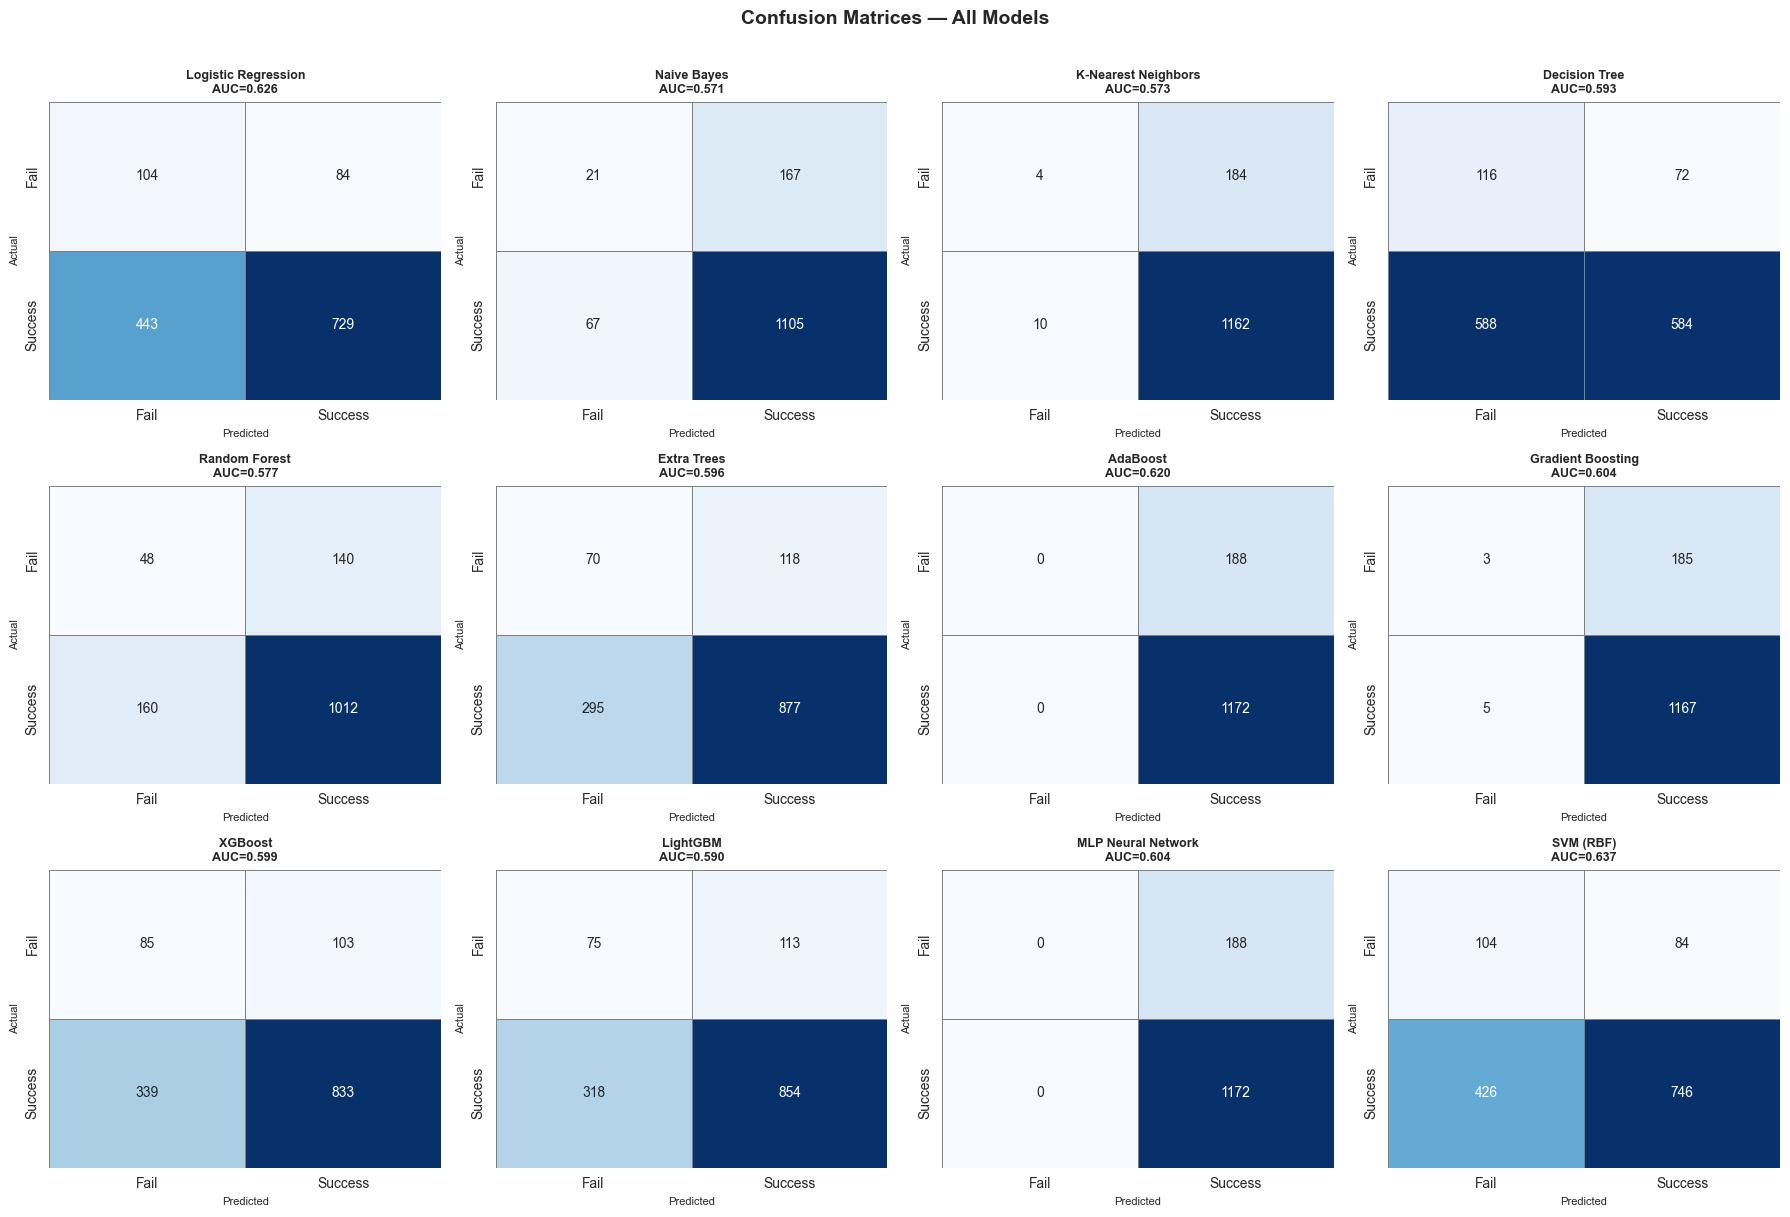

Saved: confusion_matrices_all.png


In [18]:
# ── 4×3 grid of confusion matrices for all 12 models ──────────────────────
model_names = list(MODELS.keys())
n_models    = len(model_names)
n_cols      = 4
n_rows      = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, name in enumerate(model_names):
    pipe   = trained_pipelines[name]
    y_pred = pipe.predict(X_test)
    cm_    = confusion_matrix(y_test, y_pred)
    auc    = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    axes[i].set_title(f'{name}\nAUC={auc:.3f}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('Actual', fontsize=8)

# Hide unused axes
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/images/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all.png')

## 12. Save Best Model and Results

In [19]:
# ── Save best model pipeline ───────────────────────────────────────────────
joblib.dump(trained_pipelines[best_model_name], f'outputs/models/best_model_{best_model_name.replace(" ", "_")}.pkl')
print(f'Saved best model: outputs/models/best_model_{best_model_name.replace(" ", "_")}.pkl')

# Save all results to CSV
results_df.to_csv('outputs/ml_benchmark_results.csv', index=False)
print('Saved benchmark results: outputs/ml_benchmark_results.csv')

# Save cross-validation results
cv_df.to_csv('outputs/cv_results.csv', index=False)
print('Saved CV results: outputs/cv_results.csv')

Saved best model: outputs/models/best_model_SVM_(RBF).pkl
Saved benchmark results: outputs/ml_benchmark_results.csv
Saved CV results: outputs/cv_results.csv


## 13. Summary

In [20]:
# ── Final summary dashboard ────────────────────────────────────────────────
print('=' * 70)
print('  TB TREATMENT OUTCOME PREDICTION — BENCHMARK SUMMARY')
print('=' * 70)
print(f'  Dataset : {len(df):,} records (Success: {y.sum():,} | Failure: {(y==0).sum():,})')
print(f'  Features: {X.shape[1]} ({len(NUM_FEATURES)} numeric, {len(CAT_FEATURES)} categorical, {len(ORD_FEATURES)} ordinal)')
print(f'  Split   : 80% train / 20% test (stratified)')
print()
print(f'  Top 5 Models by ROC-AUC:')
for _, row in results_df.head(5).iterrows():
    marker = ' ◄ BEST' if row['Model'] == best_model_name else ''
    print(f"    {row.name}. {row['Model']:<28} AUC={row['ROC-AUC']:.4f}  F1={row['F1-Score']:.4f}{marker}")
print()
print(f'  Best Model  : {best_model_name}')
best_row = results_df[results_df['Model'] == best_model_name].iloc[0]
print(f'  Accuracy    : {best_row["Accuracy"]:.4f}')
print(f'  Precision   : {best_row["Precision"]:.4f}')
print(f'  Recall      : {best_row["Recall"]:.4f}')
print(f'  F1-Score    : {best_row["F1-Score"]:.4f}')
print(f'  ROC-AUC     : {best_row["ROC-AUC"]:.4f}')
print('=' * 70)
print()
print('  Outputs saved to outputs/')
print('    • ml_benchmark_results.csv')
print('    • cv_results.csv')
print('    • models/best_model_*.pkl')
print('    • images/*.png')
print('=' * 70)

  TB TREATMENT OUTCOME PREDICTION — BENCHMARK SUMMARY
  Dataset : 6,797 records (Success: 5,858 | Failure: 939)
  Features: 11 (3 numeric, 7 categorical, 1 ordinal)
  Split   : 80% train / 20% test (stratified)

  Top 5 Models by ROC-AUC:
    1. SVM (RBF)                    AUC=0.6367  F1=0.7453 ◄ BEST
    2. Logistic Regression          AUC=0.6259  F1=0.7345
    3. AdaBoost                     AUC=0.6204  F1=0.9258
    4. Gradient Boosting            AUC=0.6040  F1=0.9247
    5. MLP Neural Network           AUC=0.6036  F1=0.9258

  Best Model  : SVM (RBF)
  Accuracy    : 0.6250
  Precision   : 0.8988
  Recall      : 0.6365
  F1-Score    : 0.7453
  ROC-AUC     : 0.6367

  Outputs saved to outputs/
    • ml_benchmark_results.csv
    • cv_results.csv
    • models/best_model_*.pkl
    • images/*.png
